# 04: IMDb Relationships & Joins (shows.db)
This notebook demonstrates advanced relational SQL concepts such as **INNER JOINs**, **Multi-table Joins**, and **Subqueries** using the IMDb shows database (`shows.db`).

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = os.path.join("..", "databases", "shows.db")
conn = sqlite3.connect(db_path)

### 1. Standard INNER JOIN
**What SQL concept is demonstrated?**
Linking two tables (`shows` and `ratings`) via their common key (`show_id` / `id`) to display show titles alongside ratings.

In [2]:
# Join shows and ratings tables to find the highest-rated shows of 2022 with > 50,000 votes
query = """
SELECT s.title, s.year, r.rating, r.votes
FROM shows s
INNER JOIN ratings r ON s.id = r.show_id
WHERE s.year = 2022 AND r.votes > 50000
ORDER BY r.rating DESC
LIMIT 5;
"""
pd.read_sql_query(query, conn)

,title,year,rating,votes
0,Bleach: Thousand-Year Blood War,2022,9.0,66874
1,Severance,2022,8.7,349451
2,Andor,2022,8.6,253269
3,Heartstopper,2022,8.5,89297
4,The Bear,2022,8.5,293743


### 2. Multi-Table Join (genres + shows + ratings)
**What SQL concept is demonstrated?**
Combining three tables (`shows`, `genres`, and `ratings`) to analyze average rating per genre.

In [3]:
# Join three tables to compare average rating of shows by genre (only for genres with > 100 shows)
query = """
SELECT g.genre, AVG(r.rating) AS avg_rating, COUNT(s.id) AS show_count
FROM shows s
INNER JOIN genres g ON s.id = g.show_id
INNER JOIN ratings r ON s.id = r.show_id
GROUP BY g.genre
HAVING show_count > 100
ORDER BY avg_rating DESC;
"""
df_genres = pd.read_sql_query(query, conn)
df_genres

,genre,avg_rating,show_count
0,Documentary,7.304508,11645
1,Western,7.278358,134
2,History,7.264959,2948
3,Biography,7.225042,1182
4,War,7.129756,615
5,Short,7.024910,1112
6,Adventure,7.014302,6824
7,Sport,6.996998,2232
8,Mystery,6.964866,3461
9,Fantasy,6.946256,3312


### 3. Visualizing Ratings by Genre
Let's visualize the average ratings of different genres using a bar chart.

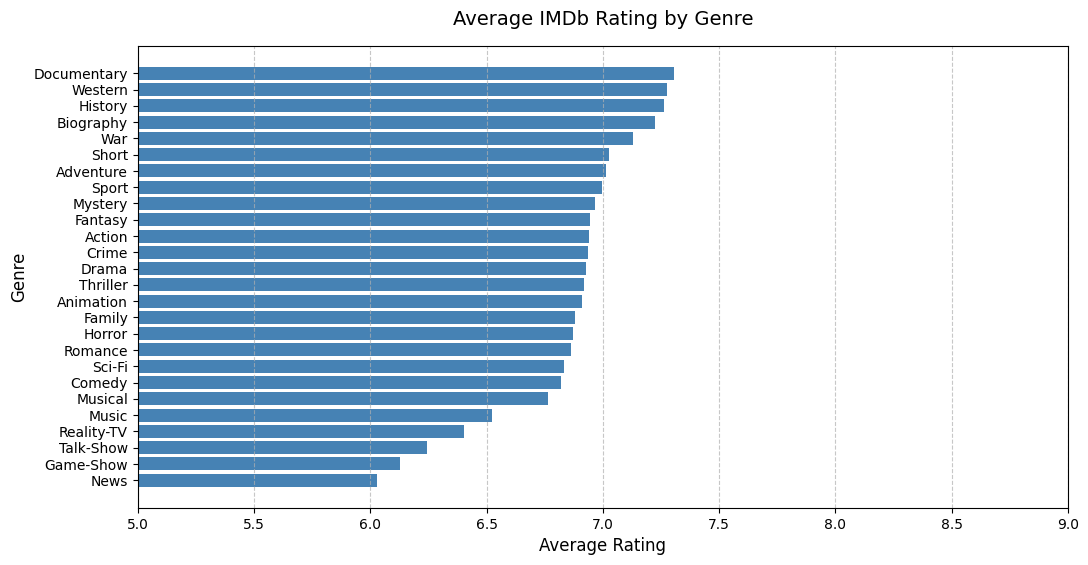

In [4]:
plt.figure(figsize=(12, 6))
plt.barh(df_genres['genre'], df_genres['avg_rating'], color='#4682B4')
plt.xlim(5, 9)  # Crop rating axis to focus on variation
plt.title('Average IMDb Rating by Genre', fontsize=14, pad=15)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis() # Highest rating on top
plt.show()

### 4. Many-to-Many Join (shows + stars + people)
**What SQL concept is demonstrated?**
Querying cast actors of a particular show using a junction table (`stars`).

In [5]:
# Querying all stars of 'The Office' (US version from 2005)
query = """
SELECT p.name, p.birth
FROM people p
INNER JOIN stars st ON p.id = st.person_id
INNER JOIN shows s ON st.show_id = s.id
WHERE s.title = 'The Office' AND s.year = 2005;
"""
pd.read_sql_query(query, conn)

,name,birth
0,Steve Carell,1962.0
1,Jenna Fischer,1974.0
2,John Krasinski,1979.0
3,Rainn Wilson,1966.0
4,Leslie David Baker,1958.0
5,Brian Baumgartner,NaN
6,Angela Kinsey,1971.0
7,Angela Kinsey,1971.0
8,Angela Kinsey,1971.0
9,Kate Flannery,1964.0


In [6]:
conn.close()

### Reflection
**What did I learn?**
- `INNER JOIN` allows combining data from multiple tables that share a key mapping.
- Many-to-many relationships require a middle helper table (junction table) like `stars` or `writers` to connect `shows` and `people` tables.
- Sub-query filters and multi-table joins are extremely powerful in relational database engines.